In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import sys
import os
from pathlib import Path
from datetime import datetime
from scipy.stats import lognorm

project_root = Path.cwd().parent.parent
project_root_str = str(project_root)

if project_root_str not in sys.path:
    sys.path.insert(0, project_root_str)

os.chdir(project_root_str)


from src.pipeline.calculate_evs import *
from src.utils.helper_functions import *
from src.features.ngboost_points import *
from src.features.feature_engine import FeatureEngine
from src.utils.team_info import teamStarPlayer, projectedStartingFive, mainStartingFive
from src.models.ngboost_model import predict_mean
from src.pipeline.pipeline_pts import build_ngboost_points_features

/Users/alexgonzalez/Documents/NBA-Prop-Predictor/nba_model/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ============================================================================
# 📅 DATE CONFIGURATION - Change this to analyze different dates!
# ============================================================================
ANALYSIS_DATE = "2025-12-07"  # Format: YYYY-MM-DD
# Examples:
# ANALYSIS_DATE = "2025-12-07"  # Analyze December 7th games
# ANALYSIS_DATE = "2025-11-15"  # Analyze November 15th games
# ============================================================================

pd.set_option('display.max_columns', None)

# Convert date formats
analysis_date_file_format = ANALYSIS_DATE.replace('-', '')  # YYYYMMDD for file names
analysis_date_db_format = ANALYSIS_DATE  # YYYY-MM-DD for database queries

print(f"🎯 Analyzing games from: {ANALYSIS_DATE}")
print("=" * 60)

def get_latest_file(pattern, date_str=None):
    """Get latest file matching pattern for a specific date"""
    files = list(Path('data/raw/player_lines').glob(pattern))
    if not files:
        return None
    return max(files, key=lambda p: p.stat().st_mtime)

# Load betting data for the specified date
us_file = get_latest_file(f'NBA_US_{analysis_date_file_format}*.csv')
dfs_file = get_latest_file(f'NBA_DFS_{analysis_date_file_format}*.csv')

if us_file is None:
    print(f"⚠️  No NBA_US file found for {ANALYSIS_DATE}")
    print(f"    Looking for: NBA_US_{analysis_date_file_format}*.csv")
    usData = None
else:
    usData = pd.read_csv(us_file)
    print(f"✅ Loaded US betting data: {us_file.name}")

if dfs_file is None:
    print(f"⚠️  No NBA_DFS file found for {ANALYSIS_DATE}")
    print(f"    Looking for: NBA_DFS_{analysis_date_file_format}*.csv")
    dfsData = None
else:
    dfsData = pd.read_csv(dfs_file)
    print(f"✅ Loaded DFS betting data: {dfs_file.name}")

# Load training data
print("\n📊 Loading training data...")
s26 = pd.read_csv('data/processed/training/PTS_TRAIN_26.csv').sort_values(by='GAME_DATE')
print(f"✅ Loaded training data: {len(s26)} records")

# Check if we have games for this date
games_on_date = s26[s26['GAME_DATE'] == ANALYSIS_DATE]['PLAYER_NAME'].nunique()
if games_on_date > 0:
    print(f"✅ Found {games_on_date} players with actual results for {ANALYSIS_DATE}")
else:
    print(f"⚠️  No actual results found for {ANALYSIS_DATE}")
    print(f"   - Games may not have been played yet")
    print(f"   - Data may not be updated")
    print(f"   - Check the date format")

print("=" * 60)

if dfsData is not None:
    dfsData.head()
else:
    print("No DFS data available for display")

🎯 Analyzing games from: 2025-12-07
✅ Loaded US betting data: NBA_US_20251207_163501.csv
✅ Loaded DFS betting data: NBA_DFS_20251207_163706.csv

📊 Loading training data...
✅ Loaded training data: 7774 records
✅ Found 154 players with actual results for 2025-12-07


In [11]:
# ============================================================================
# 🎯 PLAYER & BETTING LINE CONFIGURATION
# ============================================================================
name = 'Jalen Williams'
betting_line = 23.5 
odds = -110
# ============================================================================

print(f"🏀 Analyzing: {name}")
print(f"📊 Betting Line: {betting_line} points (Odds: {odds})")
print(f"📅 Game Date: {ANALYSIS_DATE}")
print("=" * 60)

# Initialize model engine
engine = FeatureEngine({
    "min_model": "src/models/saved/min_model.pkl",
    "usg_model": "src/models/saved/usg_model.pkl",
    "fga_model": "src/models/saved/fga_model.pkl",
    "ngboost_model_wrapper": "src/models/saved/pts_model_wrapper.pkl"
})

# Get prediction using the ANALYSIS_DATE
result = engine.project_player(
    player_name=name,
    data=s26,
    date=ANALYSIS_DATE,  # Uses the date set in Cell 1
    projectedStartingFive=projectedStartingFive,
    mainStartingFive=mainStartingFive,
    teamStarPlayer=teamStarPlayer,
    league_df=league_df,
    findOpp=findOpp
)

print("\n✅ Prediction Result:")
print(f"  Predicted Minutes: {result['predicted_minutes']:.2f}")
print(f"  Predicted Usage: {result['predicted_usage']:.3f}")
print(f"  Predicted FGA: {result['predicted_fga']:.2f}")
print(f"  Predicted Points: {result['predicted_points']:.2f}")
print("=" * 60)

🏀 Analyzing: Jalen Williams
📊 Betting Line: 23.5 points (Odds: -110)
📅 Game Date: 2025-12-07

✅ Prediction Result:
  Predicted Minutes: 27.41
  Predicted Usage: 0.240
  Predicted FGA: 14.57
  Predicted Points: 22.10


In [12]:
def get_actual_result(player_name, game_date, data):
    """Get actual game result for a player on a specific date"""
    player_data = data[
        (data['PLAYER_NAME'] == player_name) & 
        (data['GAME_DATE'] == game_date)
    ]
    
    if len(player_data) == 0:
        return None
    
    actual = player_data.iloc[0]
    return {
        'actual_points': actual['PTS'],
        'actual_minutes': actual['MIN'],
        'actual_fga': actual['FGA'],
        'actual_fgm': actual['FGM'],
        'actual_fg_pct': actual['FG_PCT'],
        'actual_fg3a': actual['FG3A'],
        'actual_fg3m': actual['FG3M'],
        'actual_fta': actual['FTA'],
        'actual_ftm': actual['FTM'],
        'actual_usage': actual['USG_PCT'],
        'actual_ts_pct': actual['TS_PCT'],
        'actual_plus_minus': actual['PLUS_MINUS'],
        'team_pace': actual['TEAM_PACE'],
        'opp_def_rating': actual['OPP_DEF_RATING'],
        'matchup': actual['MATCHUP'],
        'starting': actual['STARTING'],
        'team_wl': actual['WL'],
        'star_out': actual['STAR_SAT_OUT'],
        'star': actual['PLAYER_IS_TEAM_STAR']
    }

# Get actual result
actual_result = get_actual_result(name, ANALYSIS_DATE, s26)

if actual_result:
    print("=" * 60)
    print(f"ANALYSIS FOR: {name}")
    print(f"Game Date: {ANALYSIS_DATE}")
    print(f"Matchup: {actual_result['matchup']}")
    print(f"Result: {actual_result['team_wl']}")
    print("=" * 60)
    
    # Points comparison
    pred_points = result['predicted_points']
    actual_points = actual_result['actual_points']
    line_diff_pred = pred_points - betting_line
    line_diff_actual = actual_points - betting_line
    pred_error = pred_points - actual_points
    
    print(f"\n🎯 POINTS:")
    print(f"  Betting Line:        {betting_line:.2f}")
    print(f"  Model Prediction:    {pred_points:.2f} ({line_diff_pred:+.2f} vs line)")
    print(f"  Actual Result:       {actual_points:.2f} ({line_diff_actual:+.2f} vs line)")
    print(f"  Prediction Error:    {pred_error:+.2f}")
    print(f"  Error %:             {(pred_error/actual_points*100):+.1f}%")
    
    # Determine bet outcome
    print(f"\n💰 BET OUTCOME:")
    actual_hit_over = "✅" if actual_points > betting_line else "❌"
    pred_hit_over = "✅" if pred_points > betting_line else "❌"
    print(f"  Actual vs Line:      {actual_hit_over} {'OVER' if actual_points > betting_line else 'UNDER'}")
    print(f"  Model Predicted:     {pred_hit_over} {'OVER' if pred_points > betting_line else 'UNDER'}")
    print(f"  Model Correct:       {'✅ YES' if (actual_points > betting_line) == (pred_points > betting_line) else '❌ NO'}")
    
    # Minutes comparison
    pred_min = result['predicted_minutes']
    actual_min = actual_result['actual_minutes']
    min_error = pred_min - actual_min
    
    print(f"\n⏱️  MINUTES:")
    print(f"  Model Prediction:    {pred_min:.2f}")
    print(f"  Actual Result:       {actual_min:.2f}")
    print(f"  Error:               {min_error:+.2f} ({(min_error/actual_min*100):+.1f}%)")
    
    # Usage comparison
    pred_usg = result['predicted_usage']
    actual_usg = actual_result['actual_usage']
    usg_error = pred_usg - actual_usg
    
    print(f"\n📈 USAGE RATE:")
    print(f"  Model Prediction:    {pred_usg:.3f}")
    print(f"  Actual Result:       {actual_usg:.3f}")
    print(f"  Error:               {usg_error:+.3f}")
    
    # FGA comparison
    pred_fga = result['predicted_fga']
    actual_fga = actual_result['actual_fga']
    fga_error = pred_fga - actual_fga
    
    print(f"\n🏀 FIELD GOAL ATTEMPTS:")
    print(f"  Model Prediction:    {pred_fga:.2f}")
    print(f"  Actual Result:       {actual_fga:.2f}")
    print(f"  Error:               {fga_error:+.2f}")
    
    # Shooting efficiency
    actual_fg_pct = actual_result['actual_fg_pct']
    actual_ts_pct = actual_result['actual_ts_pct']
    
    print(f"\n🎯 SHOOTING EFFICIENCY:")
    print(f"  Actual FG%:          {actual_fg_pct:.3f}")
    print(f"  Actual TS%:          {actual_ts_pct:.3f}")
    print(f"  FGM/FGA:             {actual_result['actual_fgm']}/{actual_result['actual_fga']}")
    print(f"  3PM/3PA:             {actual_result['actual_fg3m']}/{actual_result['actual_fg3a']}")
    print(f"  FTM/FTA:             {actual_result['actual_ftm']}/{actual_result['actual_fta']}")
    
    # Game context
    print(f"\n🏟️  GAME CONTEXT:")
    print(f"  Starting:            {actual_result['starting']}")
    print(f"  Star Out:            {actual_result['star_out']}")
    print(f"  Star:                {actual_result['star']}")
    print(f"  Team Pace:           {actual_result['team_pace']:.2f}")
    print(f"  Opp Def Rating:      {actual_result['opp_def_rating']:.2f}")
    print(f"  Plus/Minus:          {actual_result['actual_plus_minus']:+.0f}")
    
else:
    print(f"⚠️  No actual data found for {name}")
    print("The game may not have been played yet or data hasn't been updated.")


ANALYSIS FOR: Jalen Williams
Game Date: 2025-12-07
Matchup: OKC @ UTA
Result: W

🎯 POINTS:
  Betting Line:        23.50
  Model Prediction:    22.10 (-1.40 vs line)
  Actual Result:       25.00 (+1.50 vs line)
  Prediction Error:    -2.90
  Error %:             -11.6%

💰 BET OUTCOME:
  Actual vs Line:      ✅ OVER
  Model Predicted:     ❌ UNDER
  Model Correct:       ❌ NO

⏱️  MINUTES:
  Model Prediction:    27.41
  Actual Result:       25.03
  Error:               +2.38 (+9.5%)

📈 USAGE RATE:
  Model Prediction:    0.240
  Actual Result:       0.322
  Error:               -0.082

🏀 FIELD GOAL ATTEMPTS:
  Model Prediction:    14.57
  Actual Result:       19.00
  Error:               -4.43

🎯 SHOOTING EFFICIENCY:
  Actual FG%:          0.579
  Actual TS%:          0.629
  FGM/FGA:             11/19
  3PM/3PA:             1/3
  FTM/FTA:             2/2

🏟️  GAME CONTEXT:
  Starting:            1
  Star Out:            1
  Star:                0
  Team Pace:           101.60
  Opp Def Rati

In [14]:
# Deep dive: What context did the model miss?
if actual_result:
    print("\n" + "=" * 60)
    print("🔍 WHAT CONTEXT DID THE MODEL MISS?")
    print("=" * 60)
    
    # Get player's recent games
    player_recent = s26[
        (s26['PLAYER_NAME'] == name) & 
        (s26['GAME_DATE'] < "2025-12-07")
    ].sort_values('GAME_DATE', ascending=False).head(10)
    
    # Analyze recent form
    if len(player_recent) > 0:
        print("\n📈 RECENT FORM (Last 10 games):")
        print("-" * 60)
        print(f"  Avg Points:          {player_recent['PTS'].mean():.2f}")
        print(f"  Points Std Dev:      {player_recent['PTS'].std():.2f}")
        print(f"  Avg Minutes:         {player_recent['MIN'].mean():.2f}")
        print(f"  Avg FGA:             {player_recent['FGA'].mean():.2f}")
        print(f"  Avg Usage:           {player_recent['USG_PCT'].mean():.3f}")
        print(f"  Avg TS%:             {player_recent['TS_PCT'].mean():.3f}")
        
        # Last 3 games
        last_3 = player_recent.head(3)
        print(f"\n  Last 3 games PTS:    {list(last_3['PTS'].values)}")
        print(f"  Last 3 games MIN:    {[f'{m:.1f}' for m in last_3['MIN'].values]}")
        
    # Matchup history
    opp_abbrev = s26[s26['PLAYER_NAME'] == name]['OPP_ABBREVIATION'].values[0]
    matchup_history = s26[
        (s26['PLAYER_NAME'] == name) & 
        (s26['OPP_ABBREVIATION'] == opp_abbrev)
    ].sort_values('GAME_DATE', ascending=False).head(5)
    
    if len(matchup_history) > 0:
        print(f"\n🏀 MATCHUP HISTORY vs {opp_abbrev}:")
        print("-" * 60)
        print(f"  Games Played:        {len(matchup_history)}")
        print(f"  Avg Points:          {matchup_history['PTS'].mean():.2f}")
        print(f"  Avg Minutes:         {matchup_history['MIN'].mean():.2f}")
        print(f"  Recent scores:       {list(matchup_history['PTS'].head(3).values)}")
    else:
        print(f"\n🏀 MATCHUP HISTORY vs {opp_abbrev}:")
        print("-" * 60)
        print("  No recent matchup history found")
    
    # Model component breakdown
    print("\n⚙️  MODEL COMPONENT BREAKDOWN:")
    print("-" * 60)
    
    # Minutes impact
    if actual_result and result:
        min_impact_on_pts = (actual_result['actual_minutes'] / result['predicted_minutes']) * result['predicted_points']
        print(f"  If we knew actual minutes:")
        print(f"    Adjusted prediction: {min_impact_on_pts:.2f} pts")
        print(f"    Would reduce error by: {abs(result['predicted_points'] - actual_result['actual_points']) - abs(min_impact_on_pts - actual_result['actual_points']):.2f} pts")
    
    # Usage impact
    if actual_result and result:
        usg_impact_on_pts = (actual_result['actual_usage'] / result['predicted_usage']) * result['predicted_points']
        print(f"\n  If we knew actual usage rate:")
        print(f"    Adjusted prediction: {usg_impact_on_pts:.2f} pts")
        print(f"    Would reduce error by: {abs(result['predicted_points'] - actual_result['actual_points']) - abs(usg_impact_on_pts - actual_result['actual_points']):.2f} pts")
    
    # Efficiency impact
    if actual_result:
        implied_pts_per_fga = actual_result['actual_points'] / actual_result['actual_fga'] if actual_result['actual_fga'] > 0 else 0
        expected_pts_from_fga = result['predicted_fga'] * implied_pts_per_fga
        print(f"\n  If we knew actual shooting efficiency:")
        print(f"    Actual pts/FGA:      {implied_pts_per_fga:.2f}")
        print(f"    Expected from pred FGA: {expected_pts_from_fga:.2f} pts")
    
    # Key insights
    print("\n💡 KEY INSIGHTS:")
    print("-" * 60)
    
    # Minutes variance
    if abs(min_error) > 5:
        print(f"  ⚠️  Large minutes error ({min_error:+.1f} min)")
        print(f"      Model may have missed rotations/game flow")
    
    # Usage variance
    if abs(usg_error) > 0.05:
        print(f"  ⚠️  Large usage error ({usg_error:+.3f})")
        print(f"      Model may have missed team dynamics/playmaking")
    
    # Shooting variance
    if len(player_recent) > 0:
        recent_ts = player_recent['TS_PCT'].mean()
        ts_diff = actual_result['actual_ts_pct'] - recent_ts
        if abs(ts_diff) > 0.10:
            print(f"  ⚠️  Unusual shooting performance")
            print(f"      Recent TS%: {recent_ts:.3f}, Actual: {actual_result['actual_ts_pct']:.3f}")
            print(f"      Player shot {'better' if ts_diff > 0 else 'worse'} than usual")
    
    # Game script
    if actual_result['actual_plus_minus'] < -15:
        print(f"  ⚠️  Blowout loss (Plus/Minus: {actual_result['actual_plus_minus']:+.0f})")
        print(f"      Garbage time may have affected playing time/usage")
    elif actual_result['actual_plus_minus'] > 15:
        print(f"  ⚠️  Blowout win (Plus/Minus: {actual_result['actual_plus_minus']:+.0f})")
        print(f"      May have sat out 4th quarter")
    
    # FGA variance
    if abs(fga_error) > 5:
        print(f"  ⚠️  Large FGA error ({fga_error:+.1f} attempts)")
        print(f"      Model may have missed offensive role/opportunities")



🔍 WHAT CONTEXT DID THE MODEL MISS?

📈 RECENT FORM (Last 10 games):
------------------------------------------------------------
  Avg Points:          16.00
  Points Std Dev:      4.55
  Avg Minutes:         30.08
  Avg FGA:             14.25
  Avg Usage:           0.254
  Avg TS%:             0.508

  Last 3 games PTS:    [np.int64(15), np.int64(22), np.int64(16)]
  Last 3 games MIN:    ['24.1', '32.8', '34.4']

🏀 MATCHUP HISTORY vs PHX:
------------------------------------------------------------
  Games Played:        1
  Avg Points:          11.00
  Avg Minutes:         29.05
  Recent scores:       [np.int64(11)]

⚙️  MODEL COMPONENT BREAKDOWN:
------------------------------------------------------------
  If we knew actual minutes:
    Adjusted prediction: 20.18 pts
    Would reduce error by: -1.92 pts

  If we knew actual usage rate:
    Adjusted prediction: 29.61 pts
    Would reduce error by: -1.71 pts

  If we knew actual shooting efficiency:
    Actual pts/FGA:      1.32
   

In [16]:
# Batch Analysis: Compare multiple players
def analyze_multiple_props(props_list, game_date, data, engine, projectedStartingFive, 
                           mainStartingFive, teamStarPlayer, league_df, findOpp):
    """
    Analyze multiple props at once
    
    props_list: list of dicts with keys 'name', 'line', 'odds'
    Example: [{'name': 'LeBron James', 'line': 25.5, 'odds': -110}, ...]
    """
    results = []
    
    for prop in props_list:
        player_name = prop['name']
        betting_line = prop['line']
        odds = prop.get('odds', -110)
        
        # Get prediction
        try:
            prediction = engine.project_player(
                player_name=player_name,
                data=data,
                date=game_date,
                projectedStartingFive=projectedStartingFive,
                mainStartingFive=mainStartingFive,
                teamStarPlayer=teamStarPlayer,
                league_df=league_df,
                findOpp=findOpp
            )
            
            # Get actual
            actual = get_actual_result(player_name, game_date, data)
            
            if actual and prediction:
                pred_points = prediction['predicted_points']
                actual_points = actual['actual_points']
                
                results.append({
                    'player': player_name,
                    'line': betting_line,
                    'prediction': pred_points,
                    'actual': actual_points,
                    'pred_error': pred_points - actual_points,
                    'pred_error_pct': (pred_points - actual_points) / actual_points * 100,
                    'pred_vs_line': pred_points - betting_line,
                    'actual_vs_line': actual_points - betting_line,
                    'model_correct': (actual_points > betting_line) == (pred_points > betting_line),
                    'actual_hit_over': actual_points > betting_line,
                    'pred_hit_over': pred_points > betting_line,
                    'min_pred': prediction['predicted_minutes'],
                    'min_actual': actual['actual_minutes'],
                    'min_error': prediction['predicted_minutes'] - actual['actual_minutes'],
                    'matchup': actual['matchup'],
                    'starting': actual['starting']
                })
        except Exception as e:
            print(f"Error analyzing {player_name}: {e}")
    
    return pd.DataFrame(results)

# Example: Analyze multiple props from today's games
# Uncomment and customize this section:

props_to_analyze = [
    {'name': 'Tyrese Maxey', 'line': 26.5, 'odds': -118},
    {'name': 'LeBron James', 'line': 17.5, 'odds': -110},
]

batch_results = analyze_multiple_props(
    props_to_analyze, 
    "2025-12-07", 
    s26, 
    engine,
    projectedStartingFive,
    mainStartingFive,
    teamStarPlayer,
    league_df,
    findOpp
)

print("\n" + "=" * 80)
print("📊 BATCH ANALYSIS RESULTS")
print("=" * 80)
print(batch_results.to_string(index=False))

print("\n" + "=" * 80)
print("📈 OVERALL MODEL PERFORMANCE")
print("=" * 80)
print(f"Total Props Analyzed:     {len(batch_results)}")
print(f"Model Accuracy:           {batch_results['model_correct'].mean()*100:.1f}%")
print(f"Mean Absolute Error:      {batch_results['pred_error'].abs().mean():.2f} pts")
print(f"Mean Error:               {batch_results['pred_error'].mean():.2f} pts")
print(f"RMSE:                     {np.sqrt((batch_results['pred_error']**2).mean()):.2f} pts")
print(f"\nActual Overs:             {batch_results['actual_hit_over'].sum()}/{len(batch_results)}")
print(f"Predicted Overs:          {batch_results['pred_hit_over'].sum()}/{len(batch_results)}")
print(f"\nCorrect Calls:            {batch_results['model_correct'].sum()}/{len(batch_results)}")

# Break down by prediction type
if len(batch_results) > 0:
    over_preds = batch_results[batch_results['pred_hit_over'] == True]
    under_preds = batch_results[batch_results['pred_hit_over'] == False]
    
    if len(over_preds) > 0:
        print(f"\nOVER Predictions:")
        print(f"  Count:                  {len(over_preds)}")
        print(f"  Accuracy:               {over_preds['model_correct'].mean()*100:.1f}%")
        print(f"  Avg pred vs line:       +{over_preds['pred_vs_line'].mean():.2f}")
    
    if len(under_preds) > 0:
        print(f"\nUNDER Predictions:")
        print(f"  Count:                  {len(under_preds)}")
        print(f"  Accuracy:               {under_preds['model_correct'].mean()*100:.1f}%")
        print(f"  Avg pred vs line:       {under_preds['pred_vs_line'].mean():.2f}")



📊 BATCH ANALYSIS RESULTS
      player  line  prediction  actual  pred_error  pred_error_pct  pred_vs_line  actual_vs_line  model_correct  actual_hit_over  pred_hit_over  min_pred  min_actual  min_error     matchup  starting
Tyrese Maxey  26.5   30.805234      28    2.805234       10.018692      4.305234             1.5           True             True           True 34.354191        38.8  -4.445809 PHI vs. LAL         1
LeBron James  17.5   16.566350      29  -12.433650      -42.874656     -0.933650            11.5          False             True          False 27.198032        34.2  -7.001968   LAL @ PHI         1

📈 OVERALL MODEL PERFORMANCE
Total Props Analyzed:     2
Model Accuracy:           50.0%
Mean Absolute Error:      7.62 pts
Mean Error:               -4.81 pts
RMSE:                     9.01 pts

Actual Overs:             2/2
Predicted Overs:          1/2

Correct Calls:            1/2

OVER Predictions:
  Count:                  1
  Accuracy:               100.0%
  Avg pred

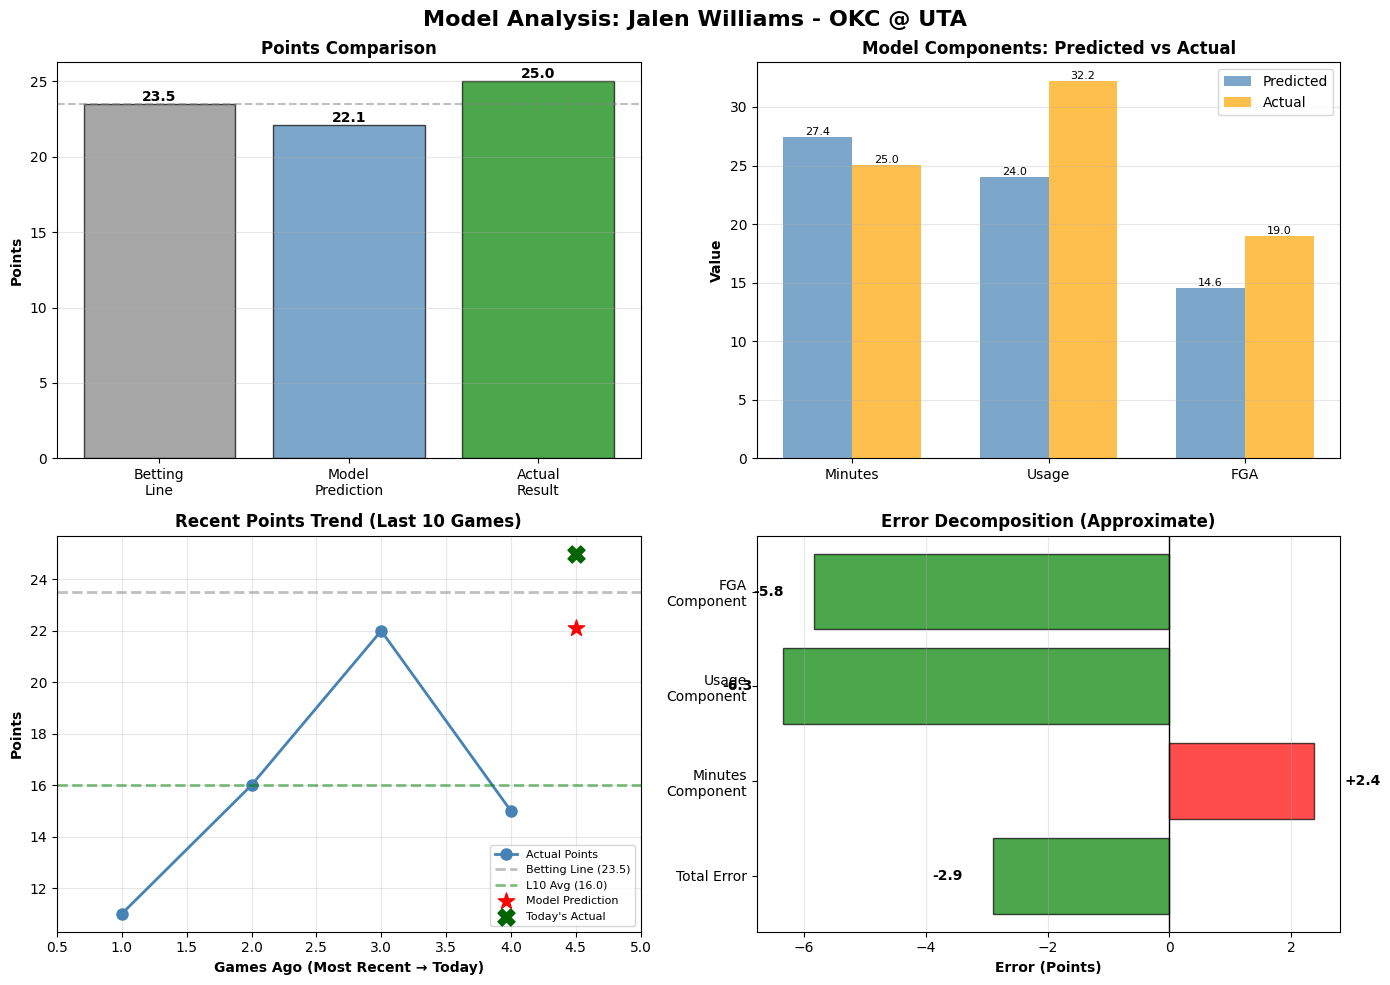

In [17]:
# Visualizations for single player analysis
if actual_result:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f'Model Analysis: {name} - {actual_result["matchup"]}', fontsize=16, fontweight='bold')
    
    # 1. Points comparison bar chart
    ax1 = axes[0, 0]
    categories = ['Betting\nLine', 'Model\nPrediction', 'Actual\nResult']
    values = [betting_line, result['predicted_points'], actual_result['actual_points']]
    colors = ['gray', 'steelblue', 'green' if actual_result['actual_points'] > betting_line else 'red']
    
    bars = ax1.bar(categories, values, color=colors, alpha=0.7, edgecolor='black')
    ax1.axhline(y=betting_line, color='gray', linestyle='--', alpha=0.5, label='Betting Line')
    ax1.set_ylabel('Points', fontweight='bold')
    ax1.set_title('Points Comparison', fontweight='bold')
    ax1.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}',
                ha='center', va='bottom', fontweight='bold')
    
    # 2. Component comparison (Min, Usage, FGA)
    ax2 = axes[0, 1]
    components = ['Minutes', 'Usage', 'FGA']
    pred_values = [result['predicted_minutes'], result['predicted_usage']*100, result['predicted_fga']]
    actual_values = [actual_result['actual_minutes'], actual_result['actual_usage']*100, actual_result['actual_fga']]
    
    x = np.arange(len(components))
    width = 0.35
    
    bars1 = ax2.bar(x - width/2, pred_values, width, label='Predicted', color='steelblue', alpha=0.7)
    bars2 = ax2.bar(x + width/2, actual_values, width, label='Actual', color='orange', alpha=0.7)
    
    ax2.set_ylabel('Value', fontweight='bold')
    ax2.set_title('Model Components: Predicted vs Actual', fontweight='bold')
    ax2.set_xticks(x)
    ax2.set_xticklabels(components)
    ax2.legend()
    ax2.grid(axis='y', alpha=0.3)
    
    # Add value labels
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.1f}',
                    ha='center', va='bottom', fontsize=8)
    
    # 3. Recent points trend
    ax3 = axes[1, 0]
    if len(player_recent) > 0:
        recent_games = player_recent.head(10).sort_values('GAME_DATE')
        game_nums = range(1, len(recent_games) + 1)
        
        ax3.plot(game_nums, recent_games['PTS'].values, marker='o', linestyle='-', 
                linewidth=2, markersize=8, color='steelblue', label='Actual Points')
        ax3.axhline(y=betting_line, color='gray', linestyle='--', linewidth=2, 
                   alpha=0.5, label=f'Betting Line ({betting_line})')
        ax3.axhline(y=recent_games['PTS'].mean(), color='green', linestyle='--', 
                   linewidth=2, alpha=0.5, label=f'L10 Avg ({recent_games["PTS"].mean():.1f})')
        
        # Mark today's prediction
        ax3.scatter([len(game_nums) + 0.5], [result['predicted_points']], 
                   color='red', s=150, marker='*', zorder=5, label='Model Prediction')
        ax3.scatter([len(game_nums) + 0.5], [actual_result['actual_points']], 
                   color='darkgreen', s=150, marker='X', zorder=5, label='Today\'s Actual')
        
        ax3.set_xlabel('Games Ago (Most Recent → Today)', fontweight='bold')
        ax3.set_ylabel('Points', fontweight='bold')
        ax3.set_title('Recent Points Trend (Last 10 Games)', fontweight='bold')
        ax3.legend(loc='best', fontsize=8)
        ax3.grid(alpha=0.3)
        ax3.set_xlim(0.5, len(game_nums) + 1)
    else:
        ax3.text(0.5, 0.5, 'No recent game data', ha='center', va='center', 
                transform=ax3.transAxes, fontsize=12)
        ax3.set_title('Recent Points Trend', fontweight='bold')
    
    # 4. Error breakdown
    ax4 = axes[1, 1]
    error_components = {
        'Total Error': pred_error,
        'Minutes\nComponent': (min_error / actual_result['actual_minutes']) * actual_result['actual_points'] if actual_result['actual_minutes'] > 0 else 0,
        'Usage\nComponent': (usg_error / actual_result['actual_usage']) * actual_result['actual_points'] if actual_result['actual_usage'] > 0 else 0,
        'FGA\nComponent': (fga_error / actual_result['actual_fga']) * actual_result['actual_points'] if actual_result['actual_fga'] > 0 else 0,
    }
    
    components_list = list(error_components.keys())
    errors = list(error_components.values())
    colors_err = ['red' if e > 0 else 'green' for e in errors]
    
    bars = ax4.barh(components_list, errors, color=colors_err, alpha=0.7, edgecolor='black')
    ax4.axvline(x=0, color='black', linestyle='-', linewidth=1)
    ax4.set_xlabel('Error (Points)', fontweight='bold')
    ax4.set_title('Error Decomposition (Approximate)', fontweight='bold')
    ax4.grid(axis='x', alpha=0.3)
    
    # Add value labels
    for i, (bar, val) in enumerate(zip(bars, errors)):
        ax4.text(val + (0.5 if val > 0 else -0.5), i, f'{val:+.1f}',
                va='center', ha='left' if val > 0 else 'right', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
else:
    print("No visualizations available - missing actual data")
